In [24]:
import math
from pathlib import Path

RESULT_DIR = Path("../result/")

In [25]:
def calc_dist(p1: tuple, p2: tuple) -> float:
    return math.dist(p1, p2)


class EnvOffline:
    def __init__(self, input_file_path: str, output_file_path: str):
        with open(input_file_path) as f:
            lines = f.readlines()
            N, M, Q, L, W = map(int, lines[0].split())
            G = list(map(int, lines[1].split()))
            rectangles = []
            for l in range(2, 2 + N):
                rectangles.append(list(map(int, lines[l].split())))
            coordinates = []
            for l in range(2 + N, 2 + N + N):
                coordinates.append(tuple(map(int, lines[l].split())))

        self.N, self.M, self.Q, self.L, self.W = N, M, Q, L, W
        self.G = G
        self.rectangles = rectangles
        self.coordinates = coordinates
        self.cneter_points = [((l + r) / 2, (c + d) / 2) for l, r, c, d in rectangles]
        self._query_history: list[str] = []

        self.input_file_path = input_file_path
        self.output_file_path = output_file_path

    def query(self, c_list: list[int]) -> list[tuple[int, int]]:
        query_str = " ".join(["?", str(len(c_list)), *map(str, c_list)])
        self._query_history.append(query_str)

        now_graph: dict[int, list] = {v: [] for v in c_list}
        for c1 in c_list:
            for c2 in c_list:
                if c1 == c2:
                    continue
                x1, y1 = self.coordinates[c1]
                x2, y2 = self.coordinates[c2]
                dist = calc_dist((x1, y1), (x2, y2))
                now_graph[c1].append((c2, dist))
                now_graph[c2].append((c1, dist))

        ans_edges, ans_v = prim(now_graph)
        return ans_edges

    def answer(
        self,
        groups: list[list[int]],
        edges: list[list[tuple[int, int]]],
    ):
        cost = 0.0
        ans_str = "!\n"
        for i in range(len(groups)):
            ans_str += " ".join(map(str, groups[i])) + "\n"
            for e in edges[i]:
                ans_str += " ".join(map(str, e)) + "\n"
                dist = calc_dist(self.coordinates[e[0]], self.coordinates[e[1]])
                cost += dist

        for query_str in self._query_history:
            ans_str += query_str + "\n"

        with open(self.output_file_path, "w") as f:
            f.write(ans_str)

        return cost

In [26]:
base_cost_txt = RESULT_DIR / "base.txt"
target_cost_txt = RESULT_DIR / "mst_test02_many_query.txt"

In [27]:
def read_txt(txt_path):
    with open(txt_path, "r") as f:
        lines = f.readlines()
        costs = [float(line.split()[1]) for line in lines[1:]]
    return costs

In [28]:
base_costs = read_txt(base_cost_txt)
target_costs = read_txt(target_cost_txt)

In [29]:
FILE_NUM = 100

envs = []
for file_num in range(FILE_NUM):
    input_file_path = f"../in/{file_num:04d}.txt"
    output_file_path = f"../out/{file_num:04d}.txt"
    #####
    env = EnvOffline(input_file_path, output_file_path)
    envs.append(env)


In [30]:
env.G

[2,
 12,
 14,
 17,
 1,
 11,
 7,
 4,
 2,
 1,
 3,
 3,
 9,
 12,
 29,
 2,
 3,
 2,
 9,
 1,
 11,
 3,
 4,
 32,
 7,
 8,
 4,
 10,
 3,
 1,
 7,
 1,
 1,
 2,
 3,
 21,
 5,
 1,
 6,
 4,
 12,
 2,
 7,
 4,
 8,
 14,
 1,
 9,
 3,
 3,
 6,
 1,
 1,
 2,
 12,
 9,
 1,
 6,
 6,
 9,
 7,
 10,
 19,
 9,
 6,
 13,
 8,
 1,
 8,
 6,
 2,
 9,
 1,
 2,
 10,
 11,
 3,
 5,
 1,
 2,
 4,
 3,
 4,
 9,
 10,
 2,
 9,
 8,
 11,
 1,
 2,
 10,
 3,
 7,
 2,
 6,
 8,
 6,
 9,
 6,
 5,
 5,
 1,
 11,
 3,
 11,
 15,
 1,
 1,
 3,
 7,
 2,
 1,
 12,
 4,
 2,
 2,
 2,
 10,
 7,
 1,
 3,
 4,
 3,
 1,
 8,
 13,
 6,
 2,
 5,
 2]

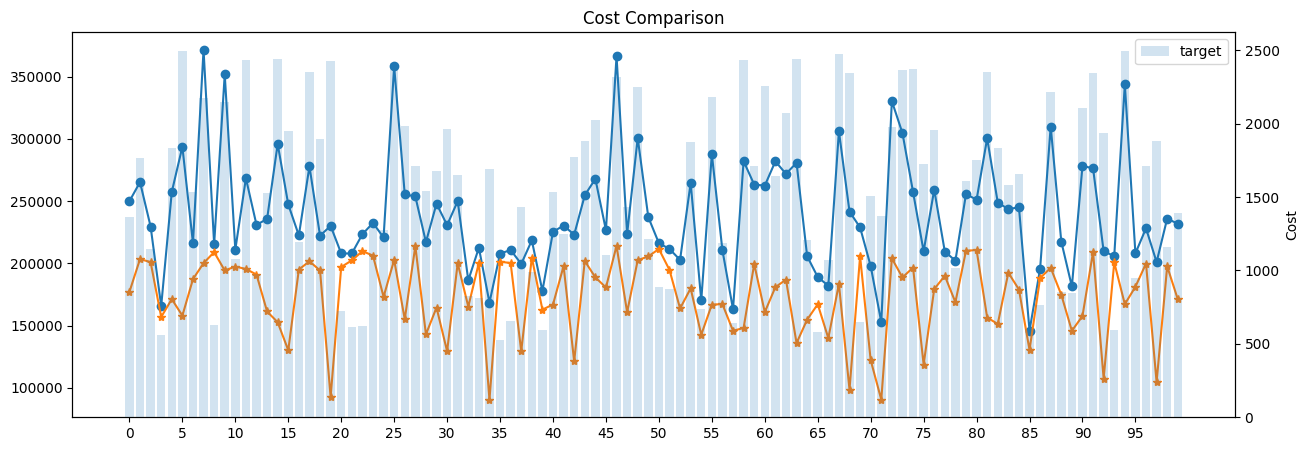

In [32]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(111)
ax1.plot(range(FILE_NUM), target_costs, label="target", marker="o")
ax1.plot(range(FILE_NUM), base_costs, label="base", marker="*")

ax2 = ax1.twinx()
ax2.bar(range(FILE_NUM), [env.W for env in envs], label="target", alpha=0.2)

plt.xticks(range(0, FILE_NUM, 5))
plt.xlabel("File Number")
plt.ylabel("Cost")
plt.title("Cost Comparison")
plt.legend()
plt.show()